# Tier Model Evaluation For LNER impact delay prediction

*author* : Gabriela Klima


This notebook builds 6 baseline models based on the Fleet delay dataset, culminating in ablation on graph topology features. The goal is to provide justification about which sources of information matter for disruption severity predicting, and whether a full Spatio-Temporal GNN is appropriate to use as a future direction

since the available data is *incident-level* (3,925 rolling-stock delay incidents, April 2022 – February 2026). We decided to reframe the target as **incident impact severity**:

- `Tot. Mins` (regression): total delay minutes caused by the incident across all affected trains
- `Trains Affect` (regression, alt target): count of trains affected — a direct proxy for spatial propagation

Both remain operationally valuable: they describe the *scope* of an incident, which is exactly what customer-comms teams need when Darwin is slow to converge.

See Report document for tabular visualisation of the tier stack.

If Tier 5 outperforms Tier 4, we have empirical evidence that station topology adds predictive signal over and above station identity, which is the core quantitative argument for an ST-GNN in future work.

## 1. Imports and Set up

In [75]:
import numpy as np # For math calculations
import pandas as pd # For data manipulation
import matplotlib.pyplot as plt # For data visualisation
import networkx as nx # for topology
import re # For filtering

# Machine learning imports
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 60)

# Setting global random seed
RANDOM_STATE = 42

## 2. Load data & first-pass quality audit

In [76]:
# Loading the dataset
delay_df = pd.read_excel('data/Fleet Dealy Data from P2301 to P2611.xlsx')

print(f'Rows: {len(delay_df):,}   Columns: {delay_df.shape[1]}')
print(f'Date range: {delay_df["Date"].min().date()} to {delay_df["Date"].max().date()}')

# Inspecting first three rows
delay_df.head(3)

Rows: 3,925   Columns: 55
Date range: 2022-04-01 to 2026-02-02


,Inc.#,Date,Status,Bugle Mgr,Bugle Mgr Title,Trust Mgr,NR Mgr,Cause,Root Cause,Root Cause Descrip.,Incid. Location,Comment,Equip.,Tot. Mins,Inc. Mins Delay Mins,Delay Mins,Capes,Pines,Calvs,FTS,Trains Affect,EQ Mins,Mgrs Note,KPI,Bugle Status,RSP Week,Inc. Pd,DfT Full,DfT Part,CaSL,PPM Fail,Incid. #,Div.s,Company,Full Canx,Part Canx,Total Canx,Sig. Lates,Total Mins,W/E,Rep. Period,KPI Cat.,CaSL's,PPM Fails,Sect1,Region.,Sect2,Day 8,NR KPI,TOC1,TOC2,Region,Funct.,Unnamed: 53,1246.5
0,480134220401,2022-04-01,A,MHB2,HITACHI - CLASS 801,MHB2,OQIE,MN,NaN,No Root Cause entered,YRK,1Y03 UNIT PROBLEMS YRK,801212,8.0,8.0,0.0,0.0,0.0,0.0,0,1,8.0,New Manager Tracking Record,701D,New,01/2023,23/01,0.0,0.0,0.0,0.0,480134,Fleet,LNER,0.0,0.0,0.0,0.0,8.0,2022-04-02,202301,7,0.0,0.0,Azuma,Azuma,Hitachi - Class 801,2022-04-08,Fleet,HB,LNER,Azuma,Azuma,NaN,NaN
1,485541220403,2022-04-03,A,MHBK,YARD - CRAIGENTINNY,MHBK,OQL9,MU,NaN,No Root Cause entered,XCN,5E98 LATE START XCN,801208,2.0,0.0,2.0,0.0,0.0,0.0,0,1,2.0,New Manager Tracking Record,701A,New,01/2023,23/01,0.0,0.0,0.0,0.0,485541,Fleet,LNER,0.0,0.0,0.0,0.0,2.0,2022-04-09,202301,7,0.0,0.0,Azuma,Depot,Craigentinny,2022-04-10,Depot,HB,LNER,Depot,Azuma,NaN,NaN
2,485877220403,2022-04-03,A,MHB1,HITACHI - CLASS 800,MHB1,OQI8,MY,MY05,Class 800/801 Couplers,KGX,1D29 6 LOST KGX,800210,6.0,6.0,0.0,0.0,0.0,0.0,0,1,6.0,UNCOUPLING ISSUE,701D,Accepted,01/2023,23/01,0.0,0.0,0.0,0.0,485877,Fleet,LNER,0.0,0.0,0.0,0.0,6.0,2022-04-09,202301,7,0.0,0.0,Azuma,Azuma,Hitachi - Class 800,2022-04-10,Fleet,HB,LNER,Azuma,Azuma,NaN,NaN


In [77]:
# For the columns that will be used (features + target), I am checking the missing sum, missing & and unique values in each
audit_cols = ['Date','Incid. Location','Cause','Root Cause','Equip.',
              'Tot. Mins','Trains Affect','Delay Mins','Region']

audit = pd.DataFrame({
    'missing':   delay_df[audit_cols].isna().sum(),
    'missing_%': (delay_df[audit_cols].isna().mean()*100).round(2),
    'n_unique':  delay_df[audit_cols].nunique()
})

# displaying the df (results)
audit

,missing,missing_%,n_unique
Date,0,0.00,1276
Incid. Location,7,0.18,403
Cause,0,0.00,17
Root Cause,133,3.39,262
Equip.,1,0.03,240
Tot. Mins,0,0.00,269
Trains Affect,0,0.00,40
Delay Mins,0,0.00,216
Region,0,0.00,4


Fixing Issues from Data Quality and Remedation Table

Fixed Issues #1,2,3,4,5

In [78]:
# (1) Normalise inconsistent location codes
LOC_FIX = {'KINGS X':'KGX', 'LEEDS':'LDS', 'NNG GRA':'NNG',
    'INV AVM':'INV', 'KDY INK':'KDY', 'DONCIEP':'DON',
    # Station aliases
    'DONCASTER':'DON', 'YORK':'YRK', 'EDINBURGH':'EDB',
    'NEWCASTLE':'NCL', 'NCASTLCEN':'NCL', 'BERWICK':'BWK',
    'NEWARKNGT':'NNG', 'LINCLNCEN':'LCN', 'HARROGATE':'HRG',
    'SKIPTON':'SKI', 'STIRLING':'STG', 'ABERDEEN':'ABD',
    'ABDN CLAY':'ABD', 'ABRDCH':'ABD', 'INVRKEITH':'INK',
    'SUNDERLND':'SUN', 'BNDSGR':'BNDSGRN',
    'GTH':'GRA', 'GTHS':'GRA',}
delay_df['Location'] = delay_df['Incid. Location'].replace(LOC_FIX)

# Drop the 0.2% with missing location or target
delay_df = delay_df.dropna(subset=['Location','Tot. Mins']).copy()

def normalise_location(raw):
    if raw in LOC_FIX:
        return LOC_FIX[raw]
    # (2) Segment codes: two tokens separated by space
    parts = str(raw).split()
    if len(parts) == 2 and len(parts[0]) <= 5 and len(parts[1]) <= 8:
        first = parts[0]
        return LOC_FIX.get(first, first)
    return raw

delay_df['Location'] = delay_df['Incid. Location'].apply(normalise_location)

# (3) Filtering Using Regex as train headcodes are accidentally entered into location field.
HEADCODE = re.compile(r'^\d[A-Z]\d{2}|^\d{4,}$')
delay_df = delay_df[~delay_df['Location'].str.match(HEADCODE, na=False)].copy()

# (4) Fill missing Root Cause
delay_df['Root Cause'] = delay_df['Root Cause'].fillna('UNK')

# (5) Cut out extreme incidents at 99th percentile for modelling only
CAP = delay_df['Tot. Mins'].quantile(0.99)
print(f'Winsorizing Tot. Mins at 99th percentile = {CAP:.0f} minutes')
delay_df['Tot. Mins_capped'] = delay_df['Tot. Mins'].clip(upper=CAP)



print(f'Clean dataset: {len(delay_df):,} rows')

Winsorizing Tot. Mins at 99th percentile = 347 minutes
Clean dataset: 3,910 rows


## 3. Load Open-Meteo weather data

- Skipping locaation metadata (rows 0-8)
- Deriving daily aggregates from hourly observations. (peak/min statistics that matter operationally)

In [79]:
# Creating file path for the weather data
WX_PATH = 'data/open-meteo-51.52N0.13E8m.csv'

# Inspecting the metadata
wx_meta = pd.read_csv(WX_PATH, nrows=8)
wx_meta

,location_id,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,0,51.523730,0.130096,8.0,0,GMT,GMT
1,1,52.936676,1.142029,0.0,0,GMT,GMT
2,2,53.531242,1.132690,0.0,0,GMT,GMT
3,3,53.805775,1.553162,0.0,0,GMT,GMT
4,4,54.258720,1.474350,0.0,0,GMT,GMT
5,5,54.979050,1.619141,0.0,0,GMT,GMT
6,6,55.955822,3.186523,0.0,0,GMT,GMT
7,7,57.473220,4.218201,0.0,0,GMT,GMT


In [80]:
# Hourly block: 286464 rows starting at skiprow 10.
# The daily-aggregate header at line 286476 is excluded by nrows.
wx_hourly = pd.read_csv(WX_PATH, skiprows=10, nrows=286464, low_memory=False)
wx_hourly['location_id'] = wx_hourly['location_id'].astype(int)
wx_hourly['time'] = pd.to_datetime(wx_hourly['time'])
wx_hourly['Date'] = wx_hourly['time'].dt.normalize()

# Renaming columns
wx_hourly = wx_hourly.rename(columns={
    'temperature_2m (°C)':   'temp_c',
    'snowfall (cm)':         'snow_cm',
    'rain (mm)':             'rain_mm',
    'precipitation (mm)':    'precip_mm',
    'visibility (m)':        'visibility_m',
    'wind_speed_10m (km/h)': 'wind_kmh',
    'wind_gusts_10m (km/h)': 'gust_kmh',
    'pressure_msl (hPa)':    'pressure_hpa',
    'snow_depth (m)':        'snow_depth_m',
    'dew_point_2m (°C)':     'dew_c',
})

# Displaying rows with hourly metrics
print(f'Hourly rows: {len(wx_hourly):,}')

# Checking to see there is hourly data for all locations
print(f'Locations:   {sorted(wx_hourly["location_id"].unique())}')

# Inspecting the hourly time
print(f'Date range:  {wx_hourly["time"].min()} to {wx_hourly["time"].max()}')

# Checking for missing values and displaying the sum
print('\nMissing per column:')

print(wx_hourly.drop(columns=['time','Date','location_id']).isna().sum())

Hourly rows: 286,464
Locations:   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Date range:  2022-01-01 00:00:00 to 2026-01-31 23:00:00

Missing per column:
temp_c              0
snow_cm             0
rain_mm             0
precip_mm           0
visibility_m        0
wind_kmh            0
gust_kmh            0
pressure_hpa        0
snow_depth_m    45786
dew_c               0
dtype: int64


### 3.1 Aggregate hourly → daily with the right statistics

The incident dataset is at day resolution, so we need daily weather per location. **Mean is the wrong aggregator for most of these variables** as the disruption signal lives in extremes !!!! :

- **Temperature:** daily min (frost / points freezing) and max (speed restrictions in heat)
- **Wind gusts:** daily max — a single 100 km/h gust causes OLE damage regardless of daily mean
- **Rain:** daily total, and daily max hourly rate (intensity to flooding; drizzle rarely disrupts)
- **Snow:** daily total, and peak depth
- **Visibility:** daily min (fog and signal sighting)
- **Pressure / dew point:** mean is fine since they are slow-moving !!

In [81]:
# snow_depth missing ~16% of the time when no snow present, we treat as 0
wx_hourly['snow_depth_m'] = wx_hourly['snow_depth_m'].fillna(0)

wx_daily = (wx_hourly
    .groupby(['location_id','Date'])
    .agg(
        temp_min      = ('temp_c',       'min'),
        temp_max      = ('temp_c',       'max'),
        temp_mean     = ('temp_c',       'mean'),
        rain_total    = ('rain_mm',      'sum'),
        rain_peak     = ('rain_mm',      'max'),
        snow_total    = ('snow_cm',      'sum'),
        snow_peak     = ('snow_depth_m', 'max'),
        precip_total  = ('precip_mm',    'sum'),
        gust_max      = ('gust_kmh',     'max'),
        wind_mean     = ('wind_kmh',     'mean'),
        vis_min       = ('visibility_m', 'min'),
        pressure_mean = ('pressure_hpa', 'mean'),
        dew_mean      = ('dew_c',        'mean'),
    )
    .reset_index())

# Operational flag features are discrete, useful for tree models
wx_daily['is_frost']   = (wx_daily['temp_min']   <    0).astype(int)
wx_daily['is_snowday'] = (wx_daily['snow_total'] >    0).astype(int)
wx_daily['is_gusty']   = (wx_daily['gust_max']   >   50).astype(int)
wx_daily['is_foggy']   = (wx_daily['vis_min']    < 1000).astype(int)

# Displaying daily weather statistics per date & location
print(f'Daily rows: {len(wx_daily):,}  ({wx_daily["location_id"].nunique()} locations × {wx_daily["Date"].nunique()} dates)')
wx_daily.head()

Daily rows: 11,936  (8 locations × 1492 dates)


,location_id,Date,temp_min,temp_max,temp_mean,rain_total,rain_peak,snow_total,snow_peak,precip_total,gust_max,wind_mean,vis_min,pressure_mean,dew_mean,is_frost,is_snowday,is_gusty,is_foggy
0,0,2022-01-01,11.6,15.1,13.108333,0.0,0.0,0.0,0.0,0.0,45.0,19.750000,24140.0,1017.616667,10.458333,0,0,0,0
1,0,2022-01-02,8.9,12.9,11.008333,1.1,0.5,0.0,0.0,1.1,51.5,22.787500,12140.0,1010.270833,8.804167,0,0,1,0
2,0,2022-01-03,7.3,10.2,8.783333,0.0,0.0,0.0,0.0,0.0,44.3,18.970833,24140.0,1007.741667,6.320833,0,0,0,0
3,0,2022-01-04,1.3,8.1,4.641667,2.2,0.7,0.0,0.0,2.2,39.6,13.841667,60.0,1001.104167,2.891667,0,0,0,1
4,0,2022-01-05,-1.0,5.7,2.404167,0.0,0.0,0.0,0.0,0.0,40.7,15.283333,24140.0,1013.125000,-0.800000,1,0,0,0


### 3.2 Map each ECML station to its nearest weather location

We map each incident location to the weather point whose latitude is closest.

**Assumption:** latitude-nearest matching is an adequate proxy for weather-at-station. (From assumption section)

In [82]:
# Approximate latitudes for each ECML station appearing in the incident data.
station_lat = {
    'KGX': 51.531, 'SVG': 51.902, 'PBO': 52.574,
    'GRA': 52.907, 'NNG': 53.005, 'RET': 53.322,
    'DON': 53.521, 'XNL': 53.534, 'LDS': 53.795,
    'WKF': 53.684, 'YRK': 53.958, 'DAR': 54.523,
    'DHM': 54.779, 'NCL': 54.969, 'BWK': 55.775,
    'EDB': 55.952, 'KDY': 56.113, 'INV': 57.479,
    # Depots and junctions handled via nearest main station latitude
    'XHT': 53.958, 'XCN': 54.969, 'BNDSGRN': 54.779,
}

wx_lats = wx_meta.set_index('location_id')['latitude']

# matching the station to the weather location, if it is a station outside of ECML, it returns None.
def nearest_wx(station):
    if station not in station_lat: return None
    return int(np.argmin(np.abs(wx_lats.values - station_lat[station])))

station_wx_map = {s: nearest_wx(s) for s in station_lat}
print('Station to weather-point assignments (sorted south to north):')

# Displaying the stations matching the location
for s in sorted(station_lat, key=lambda x: station_lat[x]):
    w = station_wx_map[s]
    print(f'  {s:<8s} (lat {station_lat[s]:5.2f}) - loc {w} (lat {wx_lats[w]:5.2f})')

Station to weather-point assignments (sorted south to north):
  KGX      (lat 51.53) - loc 0 (lat 51.52)
  SVG      (lat 51.90) - loc 0 (lat 51.52)
  PBO      (lat 52.57) - loc 1 (lat 52.94)
  GRA      (lat 52.91) - loc 1 (lat 52.94)
  NNG      (lat 53.01) - loc 1 (lat 52.94)
  RET      (lat 53.32) - loc 2 (lat 53.53)
  DON      (lat 53.52) - loc 2 (lat 53.53)
  XNL      (lat 53.53) - loc 2 (lat 53.53)
  WKF      (lat 53.68) - loc 3 (lat 53.81)
  LDS      (lat 53.80) - loc 3 (lat 53.81)
  YRK      (lat 53.96) - loc 3 (lat 53.81)
  XHT      (lat 53.96) - loc 3 (lat 53.81)
  DAR      (lat 54.52) - loc 4 (lat 54.26)
  DHM      (lat 54.78) - loc 5 (lat 54.98)
  BNDSGRN  (lat 54.78) - loc 5 (lat 54.98)
  NCL      (lat 54.97) - loc 5 (lat 54.98)
  XCN      (lat 54.97) - loc 5 (lat 54.98)
  BWK      (lat 55.77) - loc 6 (lat 55.96)
  EDB      (lat 55.95) - loc 6 (lat 55.96)
  KDY      (lat 56.11) - loc 6 (lat 55.96)
  INV      (lat 57.48) - loc 7 (lat 57.47)


### 3.3 Merge station-matched weather into the incident table

In [83]:
df = delay_df.copy() # Creating copy of previous df

df['Date']   = df['Date'].dt.normalize()
df['wx_loc'] = df['Location'].map(station_wx_map)

print(f'Incidents with a weather-location match: '
      f'{df["wx_loc"].notna().sum():,} / {len(df):,} '
      f'({df["wx_loc"].notna().mean()*100:.1f}%)')

# Unmatched locations (small depots with no ECML proximity) will fall back to KGX (loc 0)
df['wx_loc'] = df['wx_loc'].fillna(0).astype(int)

df = df.merge(wx_daily,
              left_on=['wx_loc','Date'],
              right_on=['location_id','Date'],
              how='left').drop(columns=['location_id'])

print(f'Weather merge success: {df["temp_mean"].notna().mean()*100:.1f}%')

# Fill the rare unmatched rows with the median per column
wx_cols = ['temp_min','temp_max','temp_mean','rain_total','rain_peak',
          'snow_total','snow_peak','precip_total','gust_max','wind_mean',
          'vis_min','pressure_mean','dew_mean']
for c in wx_cols:
    df[c] = df[c].fillna(df[c].median())
for c in ['is_frost','is_snowday','is_gusty','is_foggy']:
    df[c] = df[c].fillna(0).astype(int)

print(f'Final dataset: {len(df):,} rows × {df.shape[1]} columns')

Incidents with a weather-location match: 2,914 / 3,910 (74.5%)
Weather merge success: 100.0%
Final dataset: 3,910 rows × 75 columns


## 4. Exploratory analysis

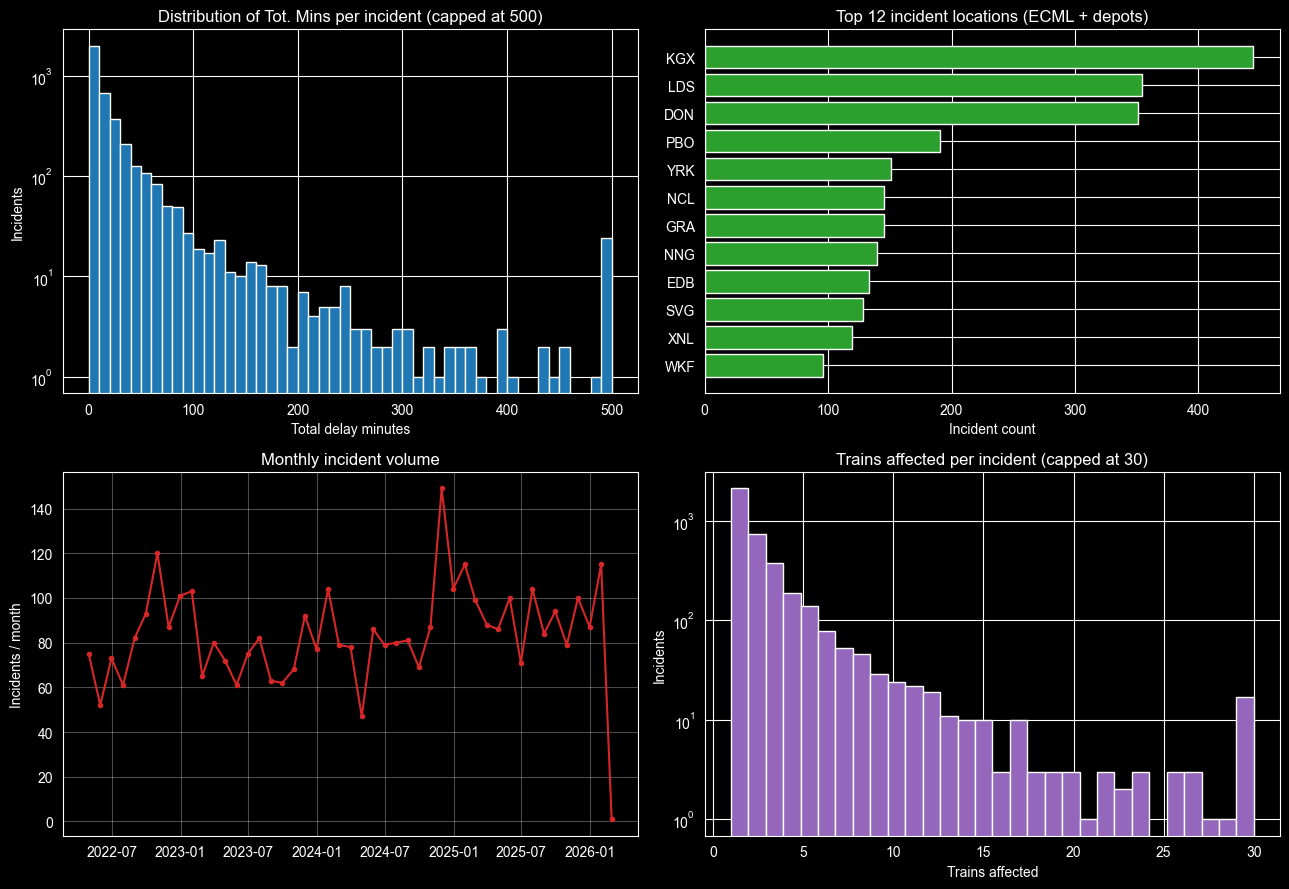

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(df['Tot. Mins'].clip(upper=500), bins=50,
               color='#1f77b4', edgecolor='white')
axes[0,0].set_title('Distribution of Tot. Mins per incident (capped at 500)')
axes[0,0].set_xlabel('Total delay minutes'); axes[0,0].set_ylabel('Incidents')
axes[0,0].set_yscale('log')

top_loc = df['Location'].value_counts().head(12)
axes[0,1].barh(top_loc.index[::-1], top_loc.values[::-1], color='#2ca02c')
axes[0,1].set_title('Top 12 incident locations (ECML + depots)')
axes[0,1].set_xlabel('Incident count')

monthly = df.set_index('Date').resample('ME').size()
axes[1,0].plot(monthly.index, monthly.values, color='#d62728', marker='o', ms=3)
axes[1,0].set_title('Monthly incident volume')
axes[1,0].set_ylabel('Incidents / month'); axes[1,0].grid(alpha=0.3)

axes[1,1].hist(df['Trains Affect'].clip(upper=30), bins=30,
               color='#9467bd', edgecolor='white')
axes[1,1].set_title('Trains affected per incident (capped at 30)')
axes[1,1].set_xlabel('Trains affected'); axes[1,1].set_ylabel('Incidents')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

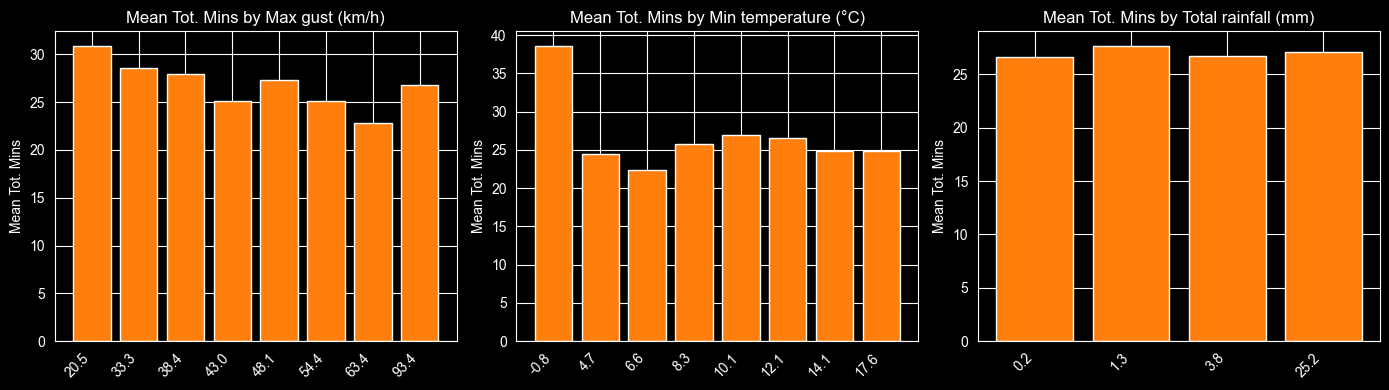

In [85]:
# Does weather actually correlate with incident severity?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['gust_max', 'temp_min', 'rain_total'],
    ['Max gust (km/h)', 'Min temperature (°C)', 'Total rainfall (mm)'],
):
    tmp = df[[col,'Tot. Mins_capped']].copy()
    tmp['bin'] = pd.qcut(tmp[col], q=8, duplicates='drop')
    agg = tmp.groupby('bin', observed=True)['Tot. Mins_capped'].mean()
    ax.bar(range(len(agg)), agg.values, color='#ff7f0e')
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([f'{b.mid:.1f}' for b in agg.index],
                        rotation=45, ha='right')
    ax.set_title(f'Mean Tot. Mins by {label}')
    ax.set_ylabel('Mean Tot. Mins')

plt.tight_layout()
plt.show()

In [86]:
by_cause = (df.groupby('Cause')
              .agg(n=('Tot. Mins','size'),
                   mean_mins=('Tot. Mins','mean'),
                   mean_trains=('Trains Affect','mean'))
              .sort_values('n', ascending=False)
              .head(12))
by_cause.round(2)

,n,mean_mins,mean_trains
Cause,,,
M7,577,21.15,2.14
M0,511,23.54,2.40
MD,469,17.92,1.75
MU,404,38.25,2.58
MN,348,64.12,4.15
MS,346,14.51,2.29
M9,255,25.52,2.37
MB,202,50.19,4.43
M1,176,72.72,4.65


## 5. Feature engineering & temporal split

 a **temporal 80/20 split**  train on the earliest 80% of the timeline, test on the most recent 20%. avoids leakage

In [87]:
df = df.sort_values('Date').reset_index(drop=True)
df['dow']        = df['Date'].dt.dayofweek
df['month']      = df['Date'].dt.month
df['is_weekend'] = (df['dow'] >= 5).astype(int)

def equip_family(x):
    s = str(x)
    if s.startswith('NL'):  return 'NL'
    if s.startswith('800'): return '800'
    if s.startswith('801'): return '801'
    m = re.match(r'^([A-Z]+)', s)
    return m.group(1) if m else 'OTH'

df['equip_fam'] = df['Equip.'].apply(equip_family)

TARGET = 'Tot. Mins_capped'

cutoff = df['Date'].quantile(0.80)
train = df[df['Date'] <= cutoff].copy()
test  = df[df['Date'] >  cutoff].copy()
print(f'Train: {len(train):,} rows  up to {cutoff.date()}')
print(f'Test:  {len(test):,} rows  after {cutoff.date()}')

Train: 3,130 rows  up to 2025-05-20
Test:  780 rows  after 2025-05-20


In [88]:
# Creating the skeleton to evalaute the models
def evaluate(name, y_true, y_pred, store):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    store.append({'Tier': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f'{name:<42s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  R²={r2:+.3f}')

results = []
y_train = train[TARGET].values
y_test  = test[TARGET].values

## 6. Tier 0 — Naive baselines

In [89]:
evaluate('T0 — Global mean',   y_test,
         np.full_like(y_test, y_train.mean(), dtype=float), results)
evaluate('T0 — Global median', y_test,
         np.full_like(y_test, np.median(y_train), dtype=float), results)

T0 — Global mean                            MAE= 25.03  RMSE= 42.70  R²=-0.014
T0 — Global median                          MAE= 18.48  RMSE= 44.59  R²=-0.106


## 7. Tier 1 — Historical conditional means

In [90]:
lookup_fine = train.groupby(['Location','Cause','dow'])[TARGET].mean()
lookup_mid  = train.groupby(['Location','Cause'])[TARGET].mean()
global_mean = y_train.mean()

def hist_predict(row):
    k = (row['Location'], row['Cause'], row['dow'])
    if k in lookup_fine.index: return lookup_fine.loc[k]
    k2 = (row['Location'], row['Cause'])
    if k2 in lookup_mid.index: return lookup_mid.loc[k2]
    return global_mean

evaluate('T1 — Historical mean (Loc×Cause×DoW)',
         y_test, test.apply(hist_predict, axis=1).values, results)

T1 — Historical mean (Loc×Cause×DoW)        MAE= 27.09  RMSE= 54.65  R²=-0.661


## 8. Tier 2 — Ridge regression with weather + calendar


In [91]:
num_feats = [
    # Weather — operational extremes
    'temp_min','temp_max','gust_max','wind_mean',
    'rain_total','rain_peak','snow_total','snow_peak',
    'vis_min','pressure_mean','dew_mean',
    # Weather flags
    'is_frost','is_snowday','is_gusty','is_foggy',
    # Calendar
    'dow','month','is_weekend',
]

lr = Ridge(alpha=1.0, random_state=RANDOM_STATE)
lr.fit(train[num_feats], y_train)
evaluate('T2 — Ridge (weather + calendar)',
         y_test, lr.predict(test[num_feats]), results)

T2 — Ridge (weather + calendar)             MAE= 25.32  RMSE= 43.01  R²=-0.029


## 9. Tier 3 — Random Forest with categorical encoding

In [92]:
cat_feats = ['Location','Cause','Root Cause','Region','equip_fam']

def build_X(df_part, numeric_cols, encoder=None, fit=False):
    if fit:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_cat = encoder.fit_transform(df_part[cat_feats])
    else:
        X_cat = encoder.transform(df_part[cat_feats])
    X_num = df_part[numeric_cols].values
    return np.hstack([X_cat, X_num]), encoder

X_train, enc = build_X(train, num_feats, fit=True)
X_test,  _   = build_X(test,  num_feats, encoder=enc)

rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=3,
                           n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
evaluate('T3 — Random Forest (cat + weather)',
         y_test, rf.predict(X_test), results)

T3 — Random Forest (cat + weather)          MAE= 24.01  RMSE= 42.74  R²=-0.016


## 10. Tier 4 — Gradient boosted trees with engineered temporal features

In [93]:
# Rolling incident counts at each location over the last 7 and 30 days.
# Shifted by 1 day so the current incident is never in its own lookback.
def add_rolling_counts(full_df):
    full_df = full_df.sort_values('Date').copy()
    full_df['loc_inc_7d']  = 0.0
    full_df['loc_inc_30d'] = 0.0
    for loc, sub in full_df.groupby('Location'):
        s = pd.Series(1, index=sub['Date']).sort_index()
        c7  = s.rolling('7D').sum().shift(1).fillna(0)
        c30 = s.rolling('30D').sum().shift(1).fillna(0)
        full_df.loc[sub.index, 'loc_inc_7d']  = c7.values
        full_df.loc[sub.index, 'loc_inc_30d'] = c30.values
    return full_df

all_df = pd.concat([train, test], ignore_index=True)
all_df = add_rolling_counts(all_df)
train = all_df[all_df['Date'] <= cutoff].copy()
test  = all_df[all_df['Date'] >  cutoff].copy()

num_feats_v2 = num_feats + ['loc_inc_7d','loc_inc_30d']

X_train2, enc2 = build_X(train, num_feats_v2, fit=True)
X_test2,  _    = build_X(test,  num_feats_v2, encoder=enc2)
y_train = train[TARGET].values
y_test  = test[TARGET].values

gbr = GradientBoostingRegressor(n_estimators=500, max_depth=5,
                                learning_rate=0.05, subsample=0.8,
                                random_state=RANDOM_STATE)
gbr.fit(X_train2, y_train)
evaluate('T4 — GBT (cat + weather + rolling)',
         y_test, gbr.predict(X_test2), results)

T4 — GBT (cat + weather + rolling)          MAE= 23.65  RMSE= 45.03  R²=-0.128


## 11. Tier 5 — GBT + graph-derived topology features


In [94]:
# confirmed depots, XNL has highest incidents
depots = {
    'XNL':       'DON',   # actually closer to LDS but allocated to DON in timetable
    'XHT':      'NCL',
    'XCN':      'EDB',
    'CRAIGNTNY':'EDB'
}

def build_ecml_graph():
    physical_connections = [
    # MAINLINE
    ('KGX', 'SVG'), #  London King's Cross to Stevenage
    ('SVG', 'HIT'),
    ('HIT', 'PBO'), # Stevenage to Peterborough
    ('PBO', 'GRA'),
    ('GRA', 'NNG'),
    ('NNG', 'RET'),
    ('RET', 'DON'),
    ('DON', 'YRK'),
    ('YRK', 'NTR'),
    ('NTR', 'DAR'),
    ('DAR', 'DHM'),
    ('DHM', 'NCL'),
    ('NCL', 'MRP'),
    ('MRP', 'ALM'),
    ('ALM', 'BWK'),
    ('BWK', 'RST'),
    ('RST', 'DUN'),
    ('DUN', 'EDB'),

    #Inverness
    ('EDB', 'HYM'),
    ('HYM', 'FKG'),
    ('FKG', 'STG'),
    ('STG', 'DBL'),
    ('DBL', 'GLA'),
    ('GLA', 'PHC'),
    ('PHC', 'DUK'),
    ('DUK', 'PIT'),
    ('PIT', 'BLA'),
    ('BLA', 'NWM'),
    ('NWM', 'KIN'),
    ('KIN', 'AVM'),
    ('AVM', 'CRB'),
    ('CRB', 'INV'),

    #Aberdeen
    ('HYM','INK'),
    ('INK', 'KDY'),
    ('KDY', 'LEU'),
    ('LEU', 'DND'),
    ('DND', 'ARB'),
    ('ARB', 'MON'),
    ('MON', 'STN'),
    ('STN', 'ABD'),

    #BRANCHES
    ('NNG', 'LCN'), #newark to lincoln

    ('DON','SEL'), #Doncaster to hull
    ('SEL', 'BRO'),
    ('BRO', 'HUL'),

    ('NTR', 'TBY'), #northallerton to middlesbrough
    ('TBY', 'MBR'),

    ('DON', 'WKF'), #Doncaster to harrogate
    ('WKF', 'LDS'),
    ('LDS', 'HRS'),
    ('HRS', 'HRG'),

    ('LDS', 'SHP'), #Leeds to Skipton
    ('SHP', 'KGH'),
    ('KGH', 'SKI'),

    ('SHP','BDS') # Shipley to Bradford Forster Square

    ]
    G = nx.Graph()
    G.add_edges_from(physical_connections)
    for depot, parent in depots.items():
        if parent in G.nodes():
            G.add_edge(parent, depot)
    return G

G = build_ecml_graph()
incident_locs = set(df['Location'].unique())
graph_locs    = set(G.nodes())
print(f'Incident locations in graph: {len(incident_locs & graph_locs)} / {len(incident_locs)}')
print(f'Missing from graph: {incident_locs - graph_locs}')
print(f'In graph but no incidents: {graph_locs - incident_locs}')

missing = incident_locs - graph_locs
print(f'Incident locations missing from graph ({len(missing)}):')
for loc in sorted(missing):
    n = (df['Location'] == loc).sum()
    print(f'  {loc:<10s} {n:>4} incidents')

deg      = dict(G.degree())
btw      = nx.betweenness_centrality(G)
evc      = nx.eigenvector_centrality_numpy(G)
dist_kgx = nx.single_source_shortest_path_length(G, 'KGX')

topo = pd.DataFrame({
    'Location':      list(deg.keys()),
    'g_degree':      [deg[n]             for n in deg],
    'g_betweenness': [btw[n]             for n in deg],
    'g_eigenvector': [evc[n]             for n in deg],
    'g_dist_to_kgx': [dist_kgx.get(n,99) for n in deg],
    'is_depot':      [int(n in depots) for n in deg],
})
topo

Incident locations in graph: 40 / 233
Missing from graph: {'DONCBDY', 'BDQ', 'CLPLLP', 'OXWLCO', 'WOOLMRGRN', 'LDY', 'HTONSJN', 'SKIRBYJ HAREPKJ', 'FYHLSJN DAR', 'COPHWJN', 'BIW', 'ARMLJCN LDS', 'DONCLCJ', 'HGT', 'SOKEJN TALNGT', 'KNGXBEL FPK', 'CRSTRSE LAWJ', 'BELFORD', 'TALNGTN', 'DLW', 'HOLME', 'TOLERTN THI', 'HAMBLNJ TEMPLHJ', 'REST402 BWK', 'FPK BELLEISLE', 'FYHLAYC', 'PMT', 'LAU', 'NXL', 'GOO', 'BLFD', 'DONCARIEP', 'HAREPKJ SKIRBY', 'HAT', 'EAG', 'PTH', 'ADWICKJ SKIRBYJ', 'DLTNECX', 'DON LOVERSALL', 'NENGLNN', 'LND', 'SHFTHLJ TEMPLHJ', 'HEATONSJN', 'PBO TALLNGTNJ', 'XBN', 'BABWTHL', 'TEMPLHJ SHFTHLJ', 'XFD', 'HOLBJCN', 'SBY', 'DONCLCJ RET', 'XKG', 'DEE', 'BESSCRJ GBROTJ', 'NSG', 'WLMRGRN WGC', 'WGC', 'APY', 'BLNGHMJ HPL', 'TEMPLHJ HAMBLNJ', 'HAYMRWJ', 'ALN', 'STOKOTJ', 'OKL', 'DONCLCJ DON', 'FYHLSJN DHM', 'SNO', 'OUT', 'CHT', 'SKELTON', 'XKB', 'HTONTMD', 'TALNGTN PBO', 'BEAL', 'TERCESL', 'CAR', 'HEATON CS', 'HEMSWTH', 'MNKTNHALJ DRM', 'SDY', 'WHRDJN', 'REST402 DUN', 'BUH', 'LOWFE

,Location,g_degree,g_betweenness,g_eigenvector,g_dist_to_kgx,is_depot
0,KGX,1,0.000000,4.331539e-03,0,0
1,SVG,2,0.034483,1.087168e-02,1,0
2,HIT,2,0.067756,2.295515e-02,2,0
3,PBO,2,0.099819,4.674318e-02,3,0
4,GRA,2,0.130672,9.436500e-02,4,0
5,NNG,3,0.191773,1.901024e-01,5,0
6,RET,2,0.215971,3.070293e-01,6,0
7,DON,5,0.539020,5.805067e-01,7,0
8,YRK,2,0.470054,3.126188e-01,8,0
9,NTR,3,0.520266,2.041313e-01,9,0


In [95]:
topo_cols = ['g_degree','g_betweenness','g_eigenvector','g_dist_to_kgx','is_depot']
default_topo = {'g_degree':0, 'g_betweenness':0, 'g_eigenvector':0,
                'g_dist_to_kgx':99, 'is_depot':0}

train = train.merge(topo, on='Location', how='left', validate='m:1')
test  = test .merge(topo, on='Location', how='left', validate='m:1')

# Any unknown X* code will still flag as depot, just with default topology (*cannot confirm which station is closest to)
depot_regex = r'^X[A-Z]{2}$'
for frame in (train, test):
    unknown_depot = frame['is_depot'].isna() & frame['Location'].str.match(depot_regex, na=False)
    frame.loc[unknown_depot, 'is_depot'] = 1
    for c, v in default_topo.items():
        frame[c] = frame[c].fillna(v)

graph_feats  = ['g_degree','g_betweenness','g_eigenvector','g_dist_to_kgx','is_depot']
num_feats_v3 = num_feats_v2 + graph_feats

X_train3, enc3 = build_X(train, num_feats_v3, fit=True)
X_test3,  _    = build_X(test,  num_feats_v3, encoder=enc3)

gbr2 = GradientBoostingRegressor(n_estimators=500, max_depth=5,
                                 learning_rate=0.05, subsample=0.8,
                                 random_state=RANDOM_STATE)
gbr2.fit(X_train3, y_train)
evaluate('T5 — GBT + graph + depots',
         y_test, gbr2.predict(X_test3), results)

T5 — GBT + graph + depots                   MAE= 23.71  RMSE= 44.56  R²=-0.104


### Bootstrap confidence intervals


In [100]:
rng = np.random.default_rng(RANDOM_STATE)
B = 2000
n = len(y_test)

pred_t4 = gbr.predict(X_test2)
pred_t5 = gbr2.predict(X_test3)

ae_t4 = np.abs(y_test - pred_t4)   # per-row absolute errors
ae_t5 = np.abs(y_test - pred_t5)
se_t4 = (y_test - pred_t4)**2      # per-row squared errors
se_t5 = (y_test - pred_t5)**2

mae_diff, rmse_diff = np.empty(B), np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, n)            # resample WITH replacement
    mae_diff[b]  = ae_t4[idx].mean()  - ae_t5[idx].mean()
    rmse_diff[b] = np.sqrt(se_t4[idx].mean()) - np.sqrt(se_t5[idx].mean())

# confidence intervals ~
def ci(x, q=(2.5, 97.5)):
    lo, hi = np.percentile(x, q)
    return x.mean(), lo, hi

print(f'MAE  (T4 − T5): {ci(mae_diff)[0]:+.3f}  '
      f'95% CI [{ci(mae_diff)[1]:+.3f}, {ci(mae_diff)[2]:+.3f}]')
print(f'RMSE (T4 − T5): {ci(rmse_diff)[0]:+.3f}  '
      f'95% CI [{ci(rmse_diff)[1]:+.3f}, {ci(rmse_diff)[2]:+.3f}]')

# one-sided bootstrap p-value that T5 beats T4
p_mae = (mae_diff <= 0).mean()
print(f'Bootstrap P(T5 no better than T4) on MAE = {p_mae:.3f}')

ΔMAE  (T4 − T5): -0.055  95% CI [-0.605, +0.497]
ΔRMSE (T4 − T5): +0.493  95% CI [-0.756, +1.851]
Bootstrap P(T5 no better than T4) on MAE = 0.572


## 12. Results comparison

In [96]:
results_df = pd.DataFrame(results).round(3)
results_df

,Tier,MAE,RMSE,R²
0,T0 — Global mean,25.029,42.705,-0.014
1,T0 — Global median,18.479,44.587,-0.106
2,T1 — Historical mean (Loc×Cause×DoW),27.090,54.647,-0.661
3,T2 — Ridge (weather + calendar),25.322,43.005,-0.029
4,T3 — Random Forest (cat + weather),24.013,42.735,-0.016
5,T4 — GBT (cat + weather + rolling),23.648,45.028,-0.128
6,T5 — GBT + graph + depots,23.709,44.555,-0.104


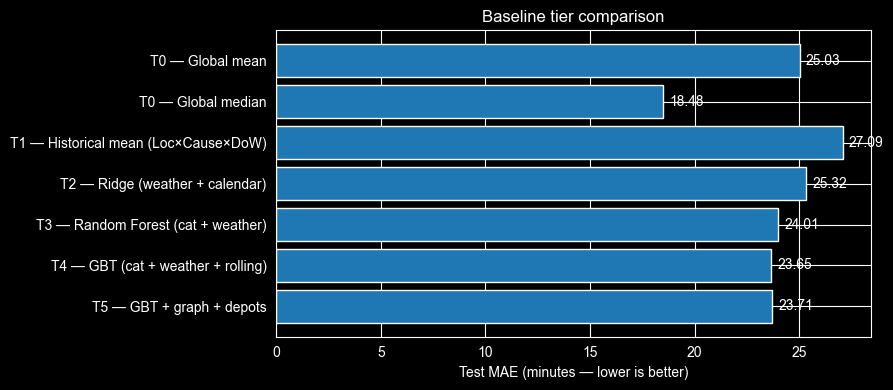

In [97]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df['Tier'][::-1], results_df['MAE'][::-1], color='#1f77b4')
ax.set_xlabel('Test MAE (minutes — lower is better)')
ax.set_title('Baseline tier comparison')
for i, v in enumerate(results_df['MAE'][::-1]):
    ax.text(v + 0.3, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

## 13. Feature importance — what's actually driving T5?

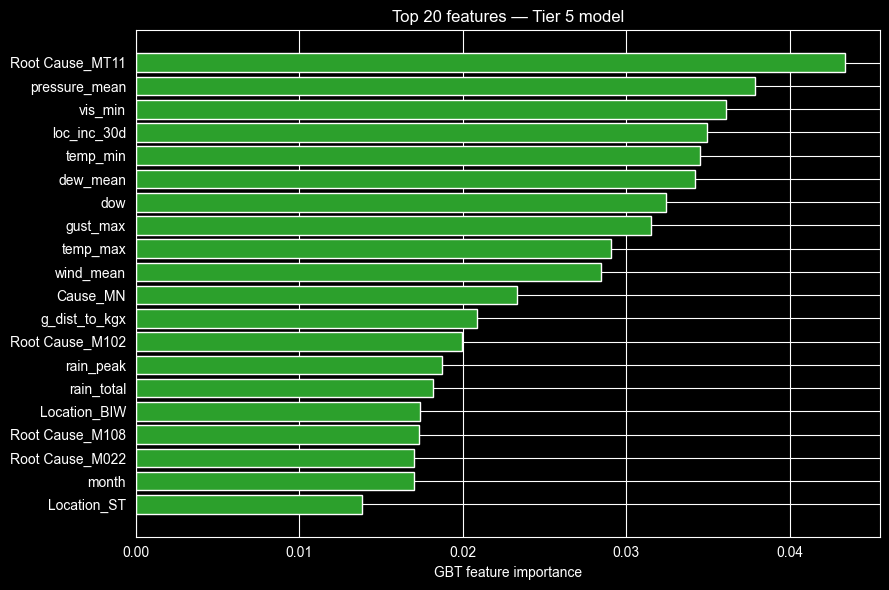

Root Cause_MT11    0.043364
pressure_mean      0.037895
vis_min            0.036095
loc_inc_30d        0.034962
temp_min           0.034527
dew_mean           0.034217
dow                0.032459
gust_max           0.031528
temp_max           0.029053
wind_mean          0.028459
Cause_MN           0.023292
g_dist_to_kgx      0.020859
Root Cause_M102    0.019948
rain_peak          0.018727
rain_total         0.018206
Location_BIW       0.017379
Root Cause_M108    0.017348
Root Cause_M022    0.017038
month              0.017024
Location_ST        0.013829
dtype: float64

In [98]:
feat_names = list(enc3.get_feature_names_out(cat_feats)) + num_feats_v3
imp = pd.Series(gbr2.feature_importances_, index=feat_names)
top = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index[::-1], top.values[::-1], color='#2ca02c')
ax.set_xlabel('GBT feature importance')
ax.set_title('Top 20 features — Tier 5 model')
plt.tight_layout()
plt.show()
top

## 14. Stratified error Test — does the model win *during disruption*?

A model that wins on average but fails on large incidents is operationally useless — large incidents are when customer comms breaks down. Report MAE separately for minor (≤2 trains) vs major (>2 trains) incidents.

In [99]:
is_major = test['Trains Affect'] > 2

for label, model, X in [
    ('T4 GBT',gbr,  X_test2),
    ('T5 GBT + graph', gbr2, X_test3)
]:
    pred = model.predict(X)
    mae_min = mean_absolute_error(y_test[~is_major], pred[~is_major])
    mae_maj = mean_absolute_error(y_test[is_major],  pred[is_major])
    print(f'{label:<20s}  minor MAE = {mae_min:6.2f}   '
          f'major MAE = {mae_maj:6.2f}   (n_major = {is_major.sum()})')

T4 GBT                minor MAE =  17.16   major MAE =  42.20   (n_major = 202)
T5 GBT + graph        minor MAE =  17.14   major MAE =  42.50   (n_major = 202)
